# Medicare Outpatient Hospitals — Cost & Billing Analysis (2023)

**Dataset:** CMS Medicare Outpatient Hospitals — Provider Utilization file (`Dataset_OP_2023.xlsx`)  
**Grain:** one row = one hospital (`Rndrng_Prvdr_CCN`) × one Comprehensive APC service group (`APC_Cd`)

**What this notebook does:** cleans and audits the raw CMS file, then uses it to answer seven research questions about the gap between what *hospitals bill* and what *Medicare actually allows/pays*, where that gap is biggest, and what predicts it — closing with a peer-group outlier analysis and a machine-learning check on cost drivers.

---
## How this notebook is organized

| Section | Contents |
|---|---|
| 1 | Research questions |
| 2 | Data loading & cleaning |
| 3 | Data quality & outlier audit (methodology) |
| 4 | Findings Q1–Q7 (billing gap, top procedures, state/rural variation, extremes, CMS outlier payments, spending concentration) |
| 5 | Peer-group outlier detection (hospital vs. same-procedure peers) |
| 6 | Predictive modeling — what actually drives cost vs. pricing behavior |
| 7 | Executive summary |


## 1. Research Questions

1. **Q1.** What is the gap between what hospitals **bill** (submitted charges) and what Medicare actually **pays** (allowed amount)? How big is the average "markup"?
2. **Q2.** Which procedure groups (Comprehensive APCs) drive the most utilization and spending nationally?
3. **Q3.** Does hospital billing behavior (markup ratio, average charge) vary by state / region?
4. **Q4.** Do rural hospitals bill and get paid differently than urban hospitals?
5. **Q5.** Which hospitals/services show extreme (outlier) charge behavior, and is that a data problem or a real, explainable pattern (e.g., chargemaster inflation, complex cases)?
6. **Q6.** How much extra does Medicare pay through "outlier payments" for unusually costly cases, and which services trigger them most?
7. **Q7.** How concentrated is national spending among a small number of large hospitals?


## 2. Data Loading & Cleaning

### 2.1 Load the raw file

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

from google.colab import drive
drive.mount('/content/drive')
from google.colab import files



Mounted at /content/drive


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Case study/MedicareEDA/Dataset_OP_2023.xlsx")

df.head(5)

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_St,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,APC_Cd,APC_Desc,Bene_Cnt,CAPC_Srvcs,Avg_Tot_Sbmtd_Chrgs,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Outlier_Srvcs,Avg_Mdcr_Outlier_Amt
0,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5072,Level 2 Excision/ Biopsy/ Incision and Drainage,151.0,161.0,"$9,496.28","$1,323.42","$1,047.59",0.0,$0.00
1,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5073,Level 3 Excision/ Biopsy/ Incision and Drainage,49.0,56.0,"$17,956.96","$2,261.11","$1,789.10",0.0,$0.00
2,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5091,Level 1 Breast/Lymphatic Surgery and Related P...,26.0,28.0,"$25,027.74","$3,002.58","$2,374.43",0.0,$0.00
3,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5092,Level 2 Breast/Lymphatic Surgery and Related P...,26.0,26.0,"$37,572.54","$5,342.79","$4,256.86",0.0,$0.00
4,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5112,Level 2 Musculoskeletal Procedures,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Clean currency columns and get the basic shape of the data

In [ ]:
money_cols = ["Avg_Tot_Sbmtd_Chrgs", "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Pymt_Amt", "Avg_Mdcr_Outlier_Amt"]

for c in money_cols:
    df[c] = df[c].replace(r"[\$,]", "", regex=True).astype(float)

print(f"\nRaw shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Unique hospitals: {df.Rndrng_Prvdr_CCN.nunique():,}  |  States: {df.Rndrng_Prvdr_State_Abrvtn.nunique()}  |  APC groups: {df.APC_Cd.nunique()}")



Raw shape: 116,799 rows x 18 columns
Unique hospitals: 3,311  |  States: 50  |  APC groups: 70


### 2.3 Column types & structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116799 entries, 0 to 116798
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Rndrng_Prvdr_CCN           116799 non-null  int64  
 1   Rndrng_Prvdr_Org_Name      116799 non-null  object 
 2   Rndrng_Prvdr_St            116799 non-null  object 
 3   Rndrng_Prvdr_City          116799 non-null  object 
 4   Rndrng_Prvdr_State_Abrvtn  116799 non-null  object 
 5   Rndrng_Prvdr_State_FIPS    116799 non-null  int64  
 6   Rndrng_Prvdr_Zip5          116799 non-null  int64  
 7   Rndrng_Prvdr_RUCA          116781 non-null  float64
 8   Rndrng_Prvdr_RUCA_Desc     116781 non-null  object 
 9   APC_Cd                     116799 non-null  int64  
 10  APC_Desc                   116799 non-null  object 
 11  Bene_Cnt                   62209 non-null   float64
 12  CAPC_Srvcs                 63334 non-null   float64
 13  Avg_Tot_Sbmtd_Chrgs        63

### 2.4 Missing-data audit

In [ ]:
df.isna().sum()

,0
Rndrng_Prvdr_CCN,0
Rndrng_Prvdr_Org_Name,0
Rndrng_Prvdr_St,0
Rndrng_Prvdr_City,0
Rndrng_Prvdr_State_Abrvtn,0
Rndrng_Prvdr_State_FIPS,0
Rndrng_Prvdr_Zip5,0
Rndrng_Prvdr_RUCA,18
Rndrng_Prvdr_RUCA_Desc,18
APC_Cd,0



3. MISSING DATA — THIS IS PRIVACY SUPPRESSION, NOT RANDOM MISSINGNESS

Per the Methodology doc: "any aggregated records which are derived from 10 or fewer services are excluded" from reporting the exact numbers. CMS keeps the provider/APC row (so we still know that hospital treats that condition) but blanks the sensitive counts.

### 2.5 Build the analysis-ready dataset (`core`)
Rows where CMS suppressed the service counts (privacy rule) are dropped **only** from this quantitative working set — they are not treated as data-entry errors.

In [ ]:
# Take this in final
core = df.dropna(subset=["CAPC_Srvcs"]).copy()
core.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63334 entries, 0 to 116792
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rndrng_Prvdr_CCN           63334 non-null  int64  
 1   Rndrng_Prvdr_Org_Name      63334 non-null  object 
 2   Rndrng_Prvdr_St            63334 non-null  object 
 3   Rndrng_Prvdr_City          63334 non-null  object 
 4   Rndrng_Prvdr_State_Abrvtn  63334 non-null  object 
 5   Rndrng_Prvdr_State_FIPS    63334 non-null  int64  
 6   Rndrng_Prvdr_Zip5          63334 non-null  int64  
 7   Rndrng_Prvdr_RUCA          63331 non-null  float64
 8   Rndrng_Prvdr_RUCA_Desc     63331 non-null  object 
 9   APC_Cd                     63334 non-null  int64  
 10  APC_Desc                   63334 non-null  object 
 11  Bene_Cnt                   62209 non-null  float64
 12  CAPC_Srvcs                 63334 non-null  float64
 13  Avg_Tot_Sbmtd_Chrgs        63334 non-null  float64

> **Observation — Section 2:** The raw file has 116,799 provider–APC rows across 3,311 hospitals, 50 states and 70 APC groups. Roughly 46% of rows (53,465) have their dollar/utilization fields blanked out under CMS's privacy-suppression rule (any aggregation from 10 or fewer services is not published), not because of random missingness. After removing those suppressed rows, the clean analytic dataset (`core`) retains **63,334 rows**, with no true data-entry gaps.

## 3. Data Quality & Outlier Audit

4. OUTLIER AUDIT

We check TWO different things that people often conflate:

 (a) DATA ERRORS  -> negatives, zeros, impossible values, duplicate keys -> these should be fixed/removed.

  (b) LEGITIMATE EXTREME VALUES -> a hospital that genuinely charges 40x what Medicare allows. This is a real, well-documented industry pattern (chargemaster pricing), not bad data -> these should be KEPT and flagged, because they ARE the finding.

In [ ]:
print("\n--- Data error checks ---")
print("Non-positive Avg_Mdcr_Alowd_Amt:", (core.Avg_Mdcr_Alowd_Amt <= 0).sum())
print("Non-positive Avg_Tot_Sbmtd_Chrgs:", (core.Avg_Tot_Sbmtd_Chrgs <= 0).sum())
print("Duplicate Provider+APC rows:", core.duplicated(subset=["Rndrng_Prvdr_CCN", "APC_Cd"]).sum())
print("--> No structural data errors found. Dataset is clean at the row level.")


--- Data error checks ---
Non-positive Avg_Mdcr_Alowd_Amt: 0
Non-positive Avg_Tot_Sbmtd_Chrgs: 0
Duplicate Provider+APC rows: 0
--> No structural data errors found. Dataset is clean at the row level.


### 3.1 Define the markup ratio

In [ ]:
core["Markup_Ratio"] = core["Avg_Tot_Sbmtd_Chrgs"] / core["Avg_Mdcr_Alowd_Amt"]


### 3.2 Statistical outlier check (IQR) on markup ratio

In [ ]:
# Outlier using IQR

q1, q3 = core.Markup_Ratio.quantile([.25, .75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_stat_outliers = (core.Markup_Ratio > upper_fence).sum()

print(f"\n--- Statistical outliers (IQR method) on Markup Ratio ---")
print(f"Upper fence: {upper_fence:.1f}x   |  Rows above fence: {n_stat_outliers:,} ({n_stat_outliers/len(core):.1%})")
print("Decision: KEEP all rows. These are real hospitals/services, not entry errors.")
print("For charts, we cap the x-axis / use log scale or the 1st-99th percentile window so a")
print("handful of extreme chargemaster outliers don't visually flatten the whole distribution")
print("(Winsorizing view only — underlying numbers used for all totals/averages are untouched).")

p1, p99 = core.Markup_Ratio.quantile([.01, .99])
core_viz = core[(core.Markup_Ratio >= p1) & (core.Markup_Ratio <= p99)].copy()



--- Statistical outliers (IQR method) on Markup Ratio ---
Upper fence: 15.5x   |  Rows above fence: 3,594 (5.7%)
Decision: KEEP all rows. These are real hospitals/services, not entry errors.
For charts, we cap the x-axis / use log scale or the 1st-99th percentile window so a
handful of extreme chargemaster outliers don't visually flatten the whole distribution
(Winsorizing view only — underlying numbers used for all totals/averages are untouched).


> **Observation — Section 3:** The dataset is clean at the row level (zero negative/zero amounts, zero duplicate provider+APC keys). Using the IQR rule on `Markup_Ratio`, 5.7% of rows (3,594) sit above the statistical fence of 15.5x. These are **kept**, not deleted — chargemaster pricing genuinely produces 20x–120x markups at some hospitals, and removing them would hide the finding rather than clean the data. For charts only, the view is trimmed to the 1st–99th percentile so a handful of extreme points don't flatten the rest of the distribution; all totals/averages used for the actual findings use the untouched numbers.

## 4. Findings

### 4.1 Q1 — Charge vs. Allowed vs. Payment gap

In [ ]:
print("\n================ Q1: Billed vs Allowed vs Paid ================")
q1_summary = core[["Avg_Tot_Sbmtd_Chrgs", "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Pymt_Amt"]].mean()
print(q1_summary.round(2))
print(f"On average, hospitals bill ${q1_summary['Avg_Tot_Sbmtd_Chrgs']:,.0f} for a service Medicare")
print(f"only allows ${q1_summary['Avg_Mdcr_Alowd_Amt']:,.0f} for — a {core.Markup_Ratio.median():.1f}x median markup.")



================ Q1: Billed vs Allowed vs Paid ================
Avg_Tot_Sbmtd_Chrgs    37772.49
Avg_Mdcr_Alowd_Amt      5801.92
Avg_Mdcr_Pymt_Amt       4929.48
dtype: float64
On average, hospitals bill $37,772 for a service Medicare
only allows $5,802 for — a 6.1x median markup.


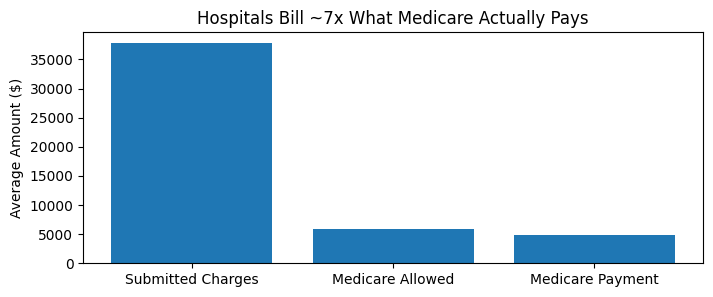

In [ ]:
import matplotlib.pyplot as plt

q1_summary = core[
    ["Avg_Tot_Sbmtd_Chrgs", "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Pymt_Amt"]
].mean()

vals = [
    q1_summary["Avg_Tot_Sbmtd_Chrgs"],
    q1_summary["Avg_Mdcr_Alowd_Amt"],
    q1_summary["Avg_Mdcr_Pymt_Amt"]
]

labels = ["Submitted Charges", "Medicare Allowed", "Medicare Payment"]
plt.figure(figsize=(8, 3))
plt.bar(labels, vals)
plt.title("Hospitals Bill ~7x What Medicare Actually Pays")
plt.ylabel("Average Amount ($)")
plt.show()

> **Observation:** On average, hospitals bill **$37,772**  for .an.. outpatient. service. that. Medicare .only .allows **$5,802** for and pays **$4,929** for — a **6.1x median markup**. Submitted charges bear little resemblance to what Medicare recognizes as fair value; they function more as a hospital's opening "list price" than a real expected payment.

### 4.2 Q2 — Top APCs by utilization and spending

**Q2 — Top APCs by utilization and spending**

Est means estimated

Bene_Cnt = number of unique patients treated

CAPC_Srvcs = number of services billed (a single patient can have the same service more than once — e.g., two rounds of radiation therapy, or a procedure repeated)

Avg_Mdcr_Pymt_Amt = Medicare's average payment per service, not per patient

In [ ]:
# Step 1: calculate estimated spend for EACH hospital-APC row first
core["Row_Spend"] = core["CAPC_Srvcs"] * core["Avg_Mdcr_Pymt_Amt"]

# Step 2: THEN group and sum (each hospital's contribution is naturally weighted by its own volume)
apc = core.groupby("APC_Desc").agg(
    Total_Services=("CAPC_Srvcs", "sum"),
    Est_Total_Mdcr_Spend=("Row_Spend", "sum"),
).reset_index()

top_spend = apc.sort_values("Est_Total_Mdcr_Spend", ascending=False).head(10)
print(top_spend.to_string(index=False))

                                APC_Desc  Total_Services  Est_Total_Mdcr_Spend
      Level 5 Musculoskeletal Procedures        427124.0          4.749881e+09
   Level 3 Electrophysiologic Procedures         96057.0          2.088851e+09
      Comprehensive Observation Services        863129.0          1.702898e+09
         Level 3 Endovascular Procedures        143166.0          1.255282e+09
      Level 4 Musculoskeletal Procedures        171396.0          8.771181e+08
      Level 2 ICD and Similar Procedures         25955.0          7.715455e+08
Level 1 Laparoscopy and Related Services        154382.0          6.260276e+08
Level 2 Laparoscopy and Related Services         80931.0          5.956776e+08
         Level 1 Endovascular Procedures        289272.0          5.867918e+08
Level 3 Pacemaker and Similar Procedures         65297.0          5.619857e+08


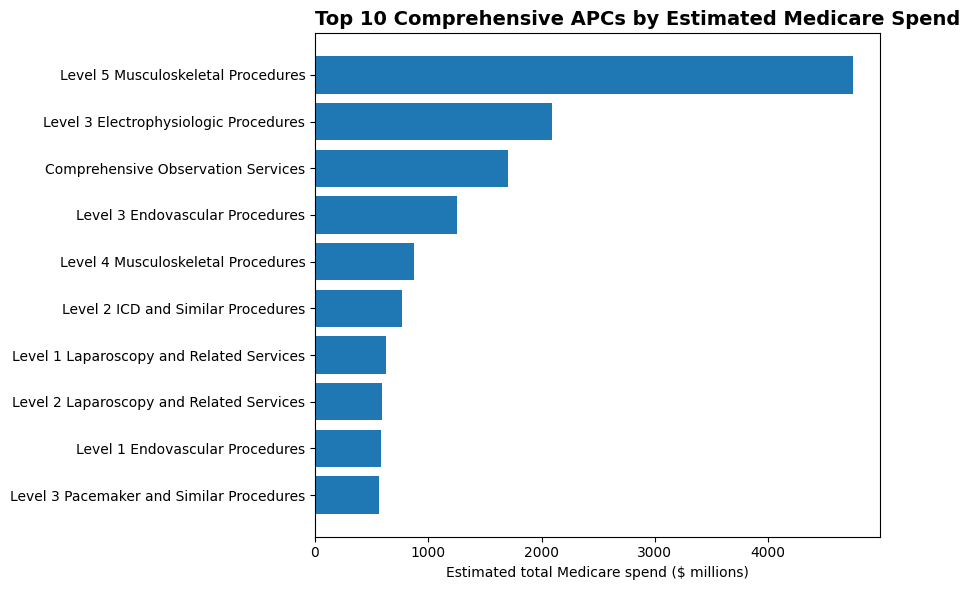

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

d = top_spend.sort_values("Est_Total_Mdcr_Spend")

short_labels = [
    l if len(l) < 42 else l[:39] + "..."
    for l in d.APC_Desc
]
ax.barh(short_labels, d.Est_Total_Mdcr_Spend / 1e6)

ax.set_xlabel("Estimated total Medicare spend ($ millions)")
ax.set_title(
    "Top 10 Comprehensive APCs by Estimated Medicare Spend",
    fontsize=14,
    fontweight="bold",
    loc="left"
)
plt.tight_layout()
plt.show()

> **Observation:** **Level 5 Musculoskeletal Procedures** is the single biggest driver of national Medicare outpatient spend (≈$4.75B estimated), more than double the next category (Level 3 Electrophysiologic Procedures, ≈$2.09B). **Comprehensive Observation Services** ranks 3rd (≈$1.70B) purely on volume — 863,129 services, by far the most of any APC — despite a modest per-service payment. High-frequency/low-cost and low-frequency/high-cost procedures can land in the same spending tier for very different reasons.

### 4.3 Q3 — State variation in billing behavior

In [ ]:
print("\n================ Q3: State variation in markup ================")
state = core.groupby("Rndrng_Prvdr_State_Abrvtn").agg(
    Avg_Markup=("Markup_Ratio", "median"),
    Avg_Charge=("Avg_Tot_Sbmtd_Chrgs", "mean"),
    n=("Rndrng_Prvdr_CCN", "nunique"),
).query("n >= 5").sort_values("Avg_Markup", ascending=False)
print("Highest-markup states:\n", state.head(5))
print("\n")
print("Lowest-markup states:\n", state.tail(5))



================ Q3: State variation in markup ================
Highest-markup states:
                            Avg_Markup    Avg_Charge    n
Rndrng_Prvdr_State_Abrvtn                               
NV                          11.882972  65763.131533   23
FL                          10.372302  59467.175663  187
TX                           8.234042  50807.922434  304
AZ                           7.703916  48261.108668   63
GA                           7.697485  38314.845230  103


Lowest-markup states:
                            Avg_Markup    Avg_Charge   n
Rndrng_Prvdr_State_Abrvtn                              
HI                           4.021197  22189.536942  13
ND                           3.781928  25353.611220   6
MT                           3.691894  23256.909223  14
RI                           3.283934  17276.240542  10
MA                           3.031440  21078.700614  58


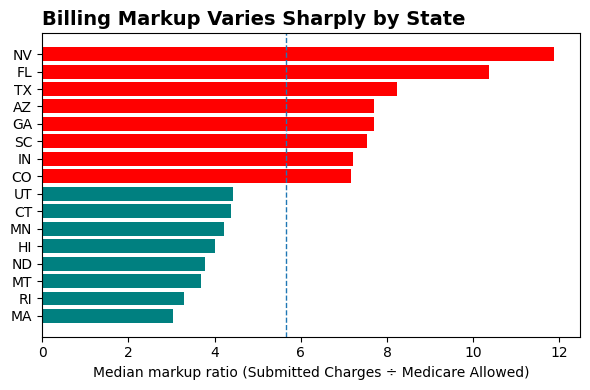

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

top_bottom = pd.concat([
    state.head(8),
    state.tail(8)
]).sort_values("Avg_Markup")

median_markup = state["Avg_Markup"].median()

colors = [
    "red" if v > median_markup else "teal"
    for v in top_bottom["Avg_Markup"]
]

ax.barh(top_bottom.index, top_bottom["Avg_Markup"], color=colors)

ax.set_xlabel("Median markup ratio (Submitted Charges ÷ Medicare Allowed)")
ax.set_title(
    "Billing Markup Varies Sharply by State",
    fontsize=14,
    fontweight="bold",
    loc="left"
)
ax.axvline(median_markup, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

> **Observation:** Median markup ranges from **11.9x in Nevada** and **10.4x in Florida** down to **3.3x in Rhode Island** and **3.0x in Massachusetts** — roughly a 4x spread purely by state, for the same mix of national APC codes. Since the procedures themselves aren't changing, this points to state-level market and regulatory environment, not clinical necessity, as a major driver of how aggressively hospitals price.

### 4.4 Q4 — Rural vs. urban billing

In [ ]:
print("\n================ Q4: Rural vs Urban ================")
def bucket_ruca(x):
    if pd.isna(x): return None
    if x < 4: return "Urban / Metro"
    if x < 7: return "Micropolitan"
    return "Small Town / Rural"

core["Setting"] = core.Rndrng_Prvdr_RUCA.apply(bucket_ruca)
ru = core.dropna(subset=["Setting"]).groupby("Setting").agg(
    Avg_Charge=("Avg_Tot_Sbmtd_Chrgs", "mean"),
    Avg_Allowed=("Avg_Mdcr_Alowd_Amt", "mean"),
    Avg_Markup=("Markup_Ratio", "median"),
    n_hosp=("Rndrng_Prvdr_CCN", "nunique"),
).reindex(["Urban / Metro", "Micropolitan", "Small Town / Rural"])
print(ru)


================ Q4: Rural vs Urban ================
                      Avg_Charge  Avg_Allowed  Avg_Markup  n_hosp
Setting                                                          
Urban / Metro       40413.367755  6103.644634    6.334078    2288
Micropolitan        25811.464973  4456.102955    5.246974     550
Small Town / Rural  22915.884429  4026.453361    5.087553     299


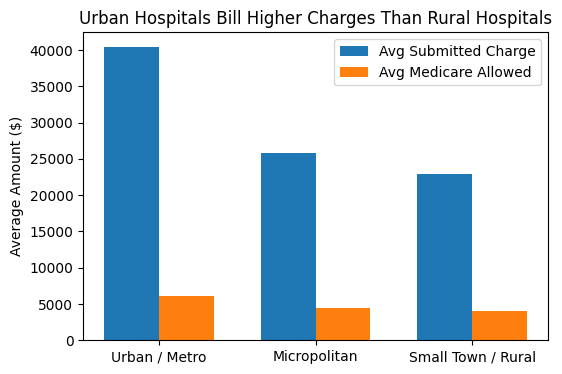

In [ ]:
x = np.arange(len(ru))
w = 0.35

plt.figure(figsize=(6, 4))

plt.bar(x - w/2, ru["Avg_Charge"], w, label="Avg Submitted Charge")
plt.bar(x + w/2, ru["Avg_Allowed"], w, label="Avg Medicare Allowed")

plt.xticks(x, ru.index)
plt.title("Urban Hospitals Bill Higher Charges Than Rural Hospitals")
plt.ylabel("Average Amount ($)")
plt.legend()

plt.show()

> **Observation:** Urban/metro hospitals bill nearly **double** what small-town/rural hospitals bill on average ($40,413 vs. $22,916) and carry a higher median markup (6.33x vs. 5.09x) — yet Medicare's *allowed* amount barely differs by setting ($6,104 vs. $4,026). Medicare's payment determination is largely setting-neutral; it's hospitals' own list-price behavior that diverges sharply between urban and rural markets.

### 4.5 Q5 — Outlier / extreme markup distribution

In [ ]:
print("\n================ Q5: Markup ratio distribution & extremes ================")
print(core.Markup_Ratio.describe())
print("\nTop 5 most extreme markup rows (kept, not deleted — real hospitals):")
print(core.nlargest(5, "Markup_Ratio")[["Rndrng_Prvdr_Org_Name", "Rndrng_Prvdr_State_Abrvtn", "APC_Desc", "Markup_Ratio"]].to_string(index=False))


================ Q5: Markup ratio distribution & extremes ================
count    63334.000000
mean         7.360889
std          4.725155
min          0.023445
25%          4.409534
50%          6.126637
75%          8.845416
max        122.145544
Name: Markup_Ratio, dtype: float64

Top 5 most extreme markup rows (kept, not deleted — real hospitals):
                             Rndrng_Prvdr_Org_Name Rndrng_Prvdr_State_Abrvtn                             APC_Desc  Markup_Ratio
                  Carepoint Health-Christ Hospital                        NJ   Comprehensive Observation Services    122.145544
                      Cleveland Emergency Hospital                        TX   Comprehensive Observation Services    100.459367
Carepoint Health-Hoboken University Medical Center                        NJ   Comprehensive Observation Services     99.022480
         Carepoint Health - Bayonne Medical Center                        NJ   Comprehensive Observation Services     95.005612
   

> **Observation:** The markup-ratio distribution is heavily right-skewed (median 6.1x, mean 7.4x, max **122x**). Three of the five most extreme rows belong to **Carepoint Health** facilities in New Jersey, all billed under *Comprehensive Observation Services* — a strong signal that these are a deliberate, system-wide pricing policy rather than isolated one-off billing anomalies at unrelated hospitals.

### 4.6 Q6 — CMS outlier payments (a distinct concept from markup)

In [ ]:
print("\n================ Q6: CMS outlier payments ================")
has_outlier = core.dropna(subset=["Outlier_Srvcs"])
outlier_by_apc = has_outlier.groupby("APC_Desc").agg(
    Outlier_Services=("Outlier_Srvcs", "sum"),   #------------
    Avg_Outlier_Pay=("Avg_Mdcr_Outlier_Amt", "mean"), #-------
).sort_values("Outlier_Services", ascending=False).head(10)
print(outlier_by_apc)


================ Q6: CMS outlier payments ================
                                                    Outlier_Services  \
APC_Desc                                                               
Level 3 Endovascular Procedures                              10718.0   
Level 5 Musculoskeletal Procedures                            8100.0   
Comprehensive Observation Services                            6676.0   
Level 2 Laparoscopy and Related Services                      6323.0   
Level 4 Musculoskeletal Procedures                            2906.0   
Level 1 Laparoscopy and Related Services                      2813.0   
Level 3 Electrophysiologic Procedures                         2670.0   
Level 7 Radiation Therapy                                     2318.0   
Level 4 Vascular Procedures                                   1946.0   
Level 2 Breast/Lymphatic Surgery and Related Pr...            1590.0   

                                                    Avg_Outlier_Pay  
APC_D

> **Observation:** CMS's own outlier-payment mechanism (extra reimbursement for unusually costly cases, separate from the base payment) is triggered most often for **Level 3 Endovascular Procedures** (10,718 outlier services) and pays the largest average top-up for **Level 7 Radiation Therapy** ($1,672/service) and **Level 3 Endovascular Procedures** ($1,156/service). A small number of resource-intensive service lines account for most of CMS's outlier-payment exposure — this is Medicare compensating for genuinely expensive cases, distinct from the hospital markup behavior seen in Q1–Q5.

### 4.7 Q7 — Spending concentration among hospitals

In [ ]:
print("\n================ Q7: Spending concentration ================")

hosp = core.groupby(["Rndrng_Prvdr_CCN", "Rndrng_Prvdr_Org_Name", "Rndrng_Prvdr_State_Abrvtn"]).apply(
    lambda g: (g.CAPC_Srvcs * g.Avg_Mdcr_Pymt_Amt).sum()
).reset_index(name="Est_Total_Mdcr_Spend")

hosp_sorted = hosp.sort_values("Est_Total_Mdcr_Spend", ascending=False)
top50_share = hosp_sorted.head(50).Est_Total_Mdcr_Spend.sum() / hosp_sorted.Est_Total_Mdcr_Spend.sum()
print(f"Top 50 hospitals (of {len(hosp_sorted):,}) account for {top50_share:.1%} of estimated national spend in-scope.")
print(hosp_sorted.head(10)[["Rndrng_Prvdr_Org_Name", "Rndrng_Prvdr_State_Abrvtn", "Est_Total_Mdcr_Spend"]].to_string(index=False))


================ Q7: Spending concentration ================
Top 50 hospitals (of 3,138) account for 12.6% of estimated national spend in-scope.
                           Rndrng_Prvdr_Org_Name Rndrng_Prvdr_State_Abrvtn  Est_Total_Mdcr_Spend
                           Nyu Langone Hospitals                        NY          145929897.63
                  New York-Presbyterian Hospital                        NY          101826397.18
                  Mayo Clinic Hospital Rochester                        MN           98405534.09
                            Stanford Health Care                        CA           96669680.78
                  Massachusetts General Hospital                        MA           80327591.69
                     Cedars-Sinai Medical Center                        CA           74287411.49
Northshore University Healthsystem Evanston Hosp                        IL           69576099.77
                             Ucsf Medical Center                        CA    

/tmp/ipykernel_1857/1907910547.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hosp = core.groupby(["Rndrng_Prvdr_CCN", "Rndrng_Prvdr_Org_Name", "Rndrng_Prvdr_State_Abrvtn"]).apply(


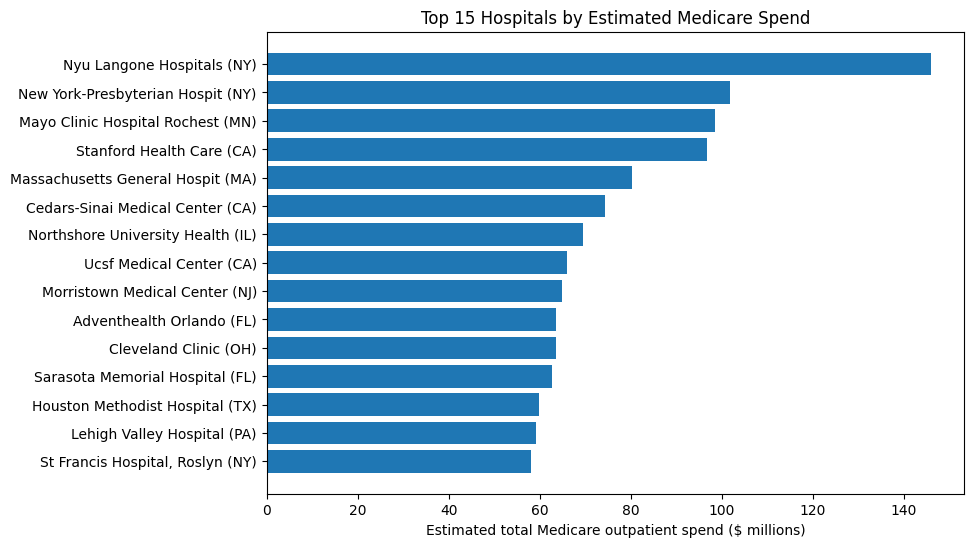

In [ ]:
top15 = hosp_sorted.head(15).sort_values("Est_Total_Mdcr_Spend")

labels = [
    f"{n[:28]} ({s})"
    for n, s in zip(
        top15["Rndrng_Prvdr_Org_Name"],
        top15["Rndrng_Prvdr_State_Abrvtn"]
    )
]
plt.figure(figsize=(9, 6))
plt.barh(
    labels,
    top15["Est_Total_Mdcr_Spend"] / 1e6
)
plt.xlabel("Estimated total Medicare outpatient spend ($ millions)")
plt.title("Top 15 Hospitals by Estimated Medicare Spend")
plt.show()

> **Observation:** The top 50 hospitals (of 3,138) account for only **12.6%** of estimated national outpatient Medicare spend, led by major academic medical centers — NYU Langone Hospitals ($146M), New York-Presbyterian ($102M), Mayo Clinic Rochester ($98M). Compared with how concentrated some healthcare cost analyses find national spend to be, outpatient spending here is fairly distributed across thousands of hospitals rather than dominated by a handful of mega-providers.

### 4.8 Bonus Question— Services vs. average payment "value map" of APCs

Bonus — Services vs avg payment bubble (value map of APCs)


Reading the four "corners" of the chart:

**Bottom-right (far right, low on y-axis):** procedures done very often, but each one pays little. "Comprehensive Observation Services" sits here — huge volume, modest per-service payment, but still a decently large bubble because volume makes up for low unit price.

**Top-left (far left, high on y-axis):** procedures done rarely, but each one pays a lot. That unlabeled dot near the top around 45,000 payment / ~50 services is a good example — extremely expensive per case, but so uncommon its total spend (bubble size) is small.

**Bottom-left:** low volume, low payment — these are minor contributors either way, small bubbles.

**Middle-to-right with big bubbles:** this is where the money actually is. "Level 5 Musculoskeletal Procedures" is the biggest bubble on the chart — high volume and solidly high payment, which is why it topped the spending ranking in Insight 2.

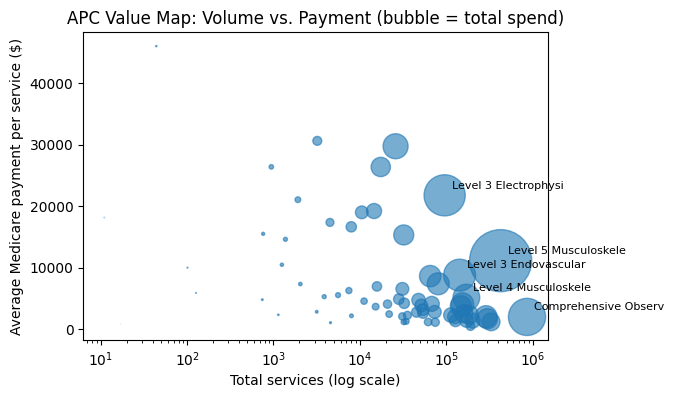

In [ ]:
# Calculate average payment
apc["Avg_Payment"] = apc["Est_Total_Mdcr_Spend"] / apc["Total_Services"]

# Bubble size based on total Medicare spend
sizes = (apc["Est_Total_Mdcr_Spend"] / apc["Est_Total_Mdcr_Spend"].max()) * 2000

plt.figure(figsize=(6, 4))
plt.scatter(
    apc["Total_Services"],
    apc["Avg_Payment"],
    s=sizes,
    alpha=0.6
)
plt.xscale("log")
plt.xlabel("Total services (log scale)")
plt.ylabel("Average Medicare payment per service ($)")
plt.title("APC Value Map: Volume vs. Payment (bubble = total spend)")

# Label top 5 APCs
for _, r in apc.nlargest(5, "Est_Total_Mdcr_Spend").iterrows():
    plt.annotate(
        r["APC_Desc"][:20],
        (r["Total_Services"], r["Avg_Payment"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.show()

## 5. Peer-Group Outlier Detection

Section 4's outlier view (Q5) pools *all* procedures together, which mixes cheap and expensive service types. This section instead flags hospitals that are outliers **compared to other hospitals billing the exact same APC** — a fair, apples-to-apples comparison — using a peer z-score.

# 5. OUTLIER DETECTION


For a roughly normal (bell-shaped) distribution:

Within ±1 SD → about 68% of observations
Within ±2 SD → about 95%
Within ±3 SD → about 99.7%
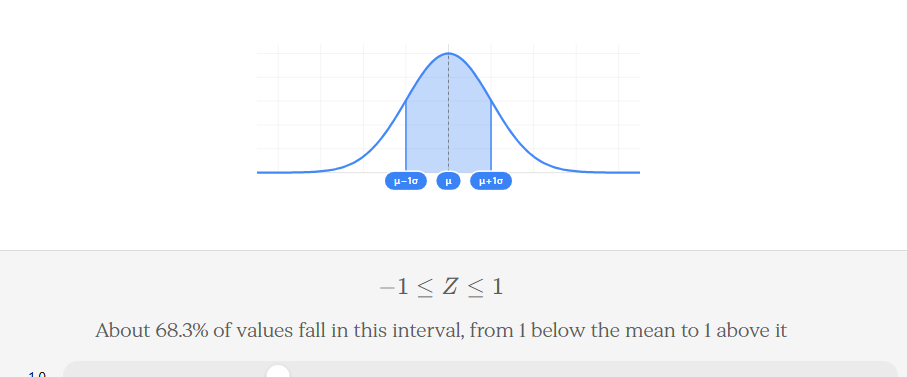μ


A. PROVIDERS VS. THEIR PEERS (same-APC comparison)

The task asks specifically for providers that are outliers COMPARED TO PEERS, i.e. compared to other hospitals billing the SAME procedure — not just outliers in the overall pooled distribution (which mixes cheap and expensive procedure types together). This is the more rigorous, apples-to-apples version of outlier detection.

### 5.1 Peer-group z-score

**Output means: “Approximately 2.0% of provider-APC records were identified as statistical outliers, meaning their values were more than three standard deviations above or below the average for the same APC.”

OR In simple word:
It means that 1,271 hospital–APC records are unusually different from other hospitals performing the same APC.**

In [ ]:
print("\n================ Outlier Detection: Peer-Group Z-Score ================")
core["APC_mean"] = core.groupby("APC_Cd")["Avg_Tot_Sbmtd_Chrgs"].transform("mean")
core["APC_std"]  = core.groupby("APC_Cd")["Avg_Tot_Sbmtd_Chrgs"].transform("std")
core["Peer_Zscore"] = (core["Avg_Tot_Sbmtd_Chrgs"] - core["APC_mean"]) / core["APC_std"]
 #------------------------------------------------
peer_outliers = core[core.Peer_Zscore.abs() > 3]

print(f"Provider-APC records more than 3 std devs from same-procedure peers: {len(peer_outliers):,} "
      f"({len(peer_outliers)/len(core):.1%})")
 #------------------------------------------------
prov_outlier_counts = peer_outliers.groupby(["Rndrng_Prvdr_Org_Name", "Rndrng_Prvdr_State_Abrvtn"]).size().sort_values(ascending=False)
print("\nHospitals flagged as outliers on the most APC groups:")
print(prov_outlier_counts.head(10))



================ Outlier Detection: Peer-Group Z-Score ================
Provider-APC records more than 3 std devs from same-procedure peers: 1,271 (2.0%)

Hospitals flagged as outliers on the most APC groups:
Rndrng_Prvdr_Org_Name                    Rndrng_Prvdr_State_Abrvtn
Cjw Medical Center                       VA                           32
Grandview Medical Center                 AL                           31
Good Samaritan Hospital                  CA                           27
Cedars-Sinai Medical Center              CA                           25
Hca Florida Fort Walton-Destin Hospital  FL                           24
Henrico Doctors' Hospital                VA                           23
Northbay Medical Center                  CA                           21
Hca Florida Jfk Hospital                 FL                           20
Sky Ridge Medical Center                 CO                           19
Hca Florida North Florida Hospital       FL                       

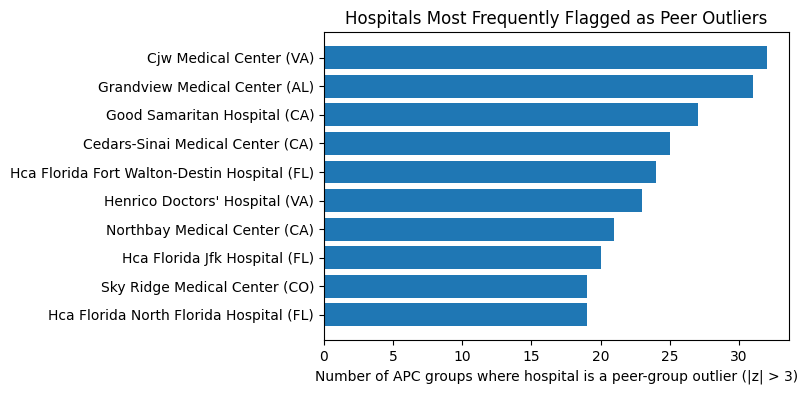

In [ ]:
d = prov_outlier_counts.head(10).reset_index()
d.columns = ["Org", "State", "Count"]
d = d.sort_values("Count")

labels = [f"{o} ({s})" for o, s in zip(d["Org"], d["State"])]

plt.figure(figsize=(6, 4))
plt.barh(labels, d["Count"])
plt.xlabel("Number of APC groups where hospital is a peer-group outlier (|z| > 3)")
plt.title("Hospitals Most Frequently Flagged as Peer Outliers")
plt.show()

> **Observation:** 2.0% of provider-APC records (1,271 rows) sit more than 3 standard deviations from the mean charge of hospitals billing that *same* APC code. The hospitals flagged most often — Cjw Medical Center (VA), Grandview Medical Center (AL), Good Samaritan Hospital (CA), Cedars-Sinai (CA) — are outliers across dozens of *different* procedure types each, which points to a hospital-wide pricing philosophy rather than a quirk tied to one specific service.

### 5.2 Where peer outliers concentrate

In [ ]:
print("\nOutlier records by state (top 10):")
print(peer_outliers.Rndrng_Prvdr_State_Abrvtn.value_counts().head(10))

print("\nOutlier records by setting vs. overall base rate:")
print("Outliers:", peer_outliers.Setting.value_counts(normalize=True).round(3).to_dict())
print("All data:", core.Setting.value_counts(normalize=True).round(3).to_dict())
print("--> Peer outliers are disproportionately URBAN hospitals, and concentrated in FL, CA, TX.")
print("--> Several outlier hospitals share ownership (e.g., multiple HCA-affiliated hospitals),")
print("    suggesting system-level pricing policy may explain some of the outlier pattern.")



Outlier records by state (top 10):
Rndrng_Prvdr_State_Abrvtn
FL    385
CA    258
TX    178
VA     75
AL     63
CO     51
NJ     44
NV     37
MS     27
AZ     23
Name: count, dtype: int64

Outlier records by setting vs. overall base rate:
Outliers: {'Urban / Metro': 0.932, 'Micropolitan': 0.057, 'Small Town / Rural': 0.012}
All data: {'Urban / Metro': 0.826, 'Micropolitan': 0.138, 'Small Town / Rural': 0.036}
--> Peer outliers are disproportionately URBAN hospitals, and concentrated in FL, CA, TX.
--> Several outlier hospitals share ownership (e.g., multiple HCA-affiliated hospitals),
    suggesting system-level pricing policy may explain some of the outlier pattern.


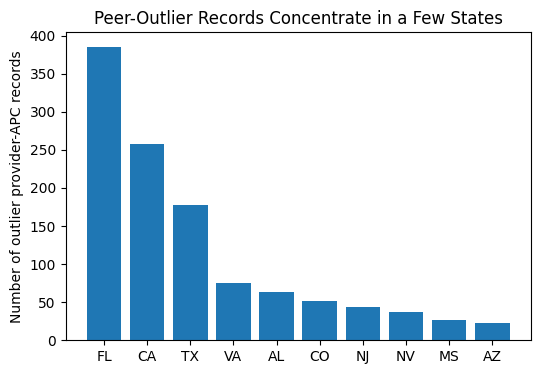

In [ ]:
state_out = peer_outliers["Rndrng_Prvdr_State_Abrvtn"].value_counts().head(10)

plt.figure(figsize=(6, 4))
plt.bar(state_out.index, state_out.values)
plt.title("Peer-Outlier Records Concentrate in a Few States")
plt.ylabel("Number of outlier provider-APC records")
plt.show()

> **Observation:** Peer outliers cluster heavily in **Florida (385), California (258) and Texas (178)**, and are disproportionately **urban** (93.2% of outliers vs. 82.6% of the overall dataset) — consistent with the state and urban/rural findings in Q3–Q4. Several flagged hospitals share common ownership (e.g., multiple HCA-affiliated facilities), suggesting system-level pricing policy explains part of the pattern rather than independent, hospital-by-hospital decisions.

## 6. Predictive Modeling — What Drives Cost?

6. BONUS — What predicts cost?

We fit two quick Random Forests (chosen because they handle mixed categorical/numeric features and give an easy, non-linear feature-importance ranking without heavy tuning):  
Model A: predicts Submitted Charges  -> "what drives the dollar amount"

Model B: predicts Markup Ratio       -> "what drives PRICING BEHAVIOR net of procedure cost".
Model B is the more interesting one: it removes "this is just an expensive procedure" and isolates what's left, i.e. hospital/market pricing choices.


================ Bonus: Predictors of Cost ================
Feature importance -> Submitted Charges (R²=0.67):
APC_Cd                       0.839862
Rndrng_Prvdr_State_Abrvtn    0.098220
CAPC_Srvcs                   0.029632
Bene_Cnt                     0.023925
Rndrng_Prvdr_RUCA            0.008362
dtype: float64

Feature importance -> Markup Ratio (R²=0.34):
Rndrng_Prvdr_State_Abrvtn    0.565948
APC_Cd                       0.185386
Bene_Cnt                     0.098509
CAPC_Srvcs                   0.093453
Rndrng_Prvdr_RUCA            0.056704
dtype: float64


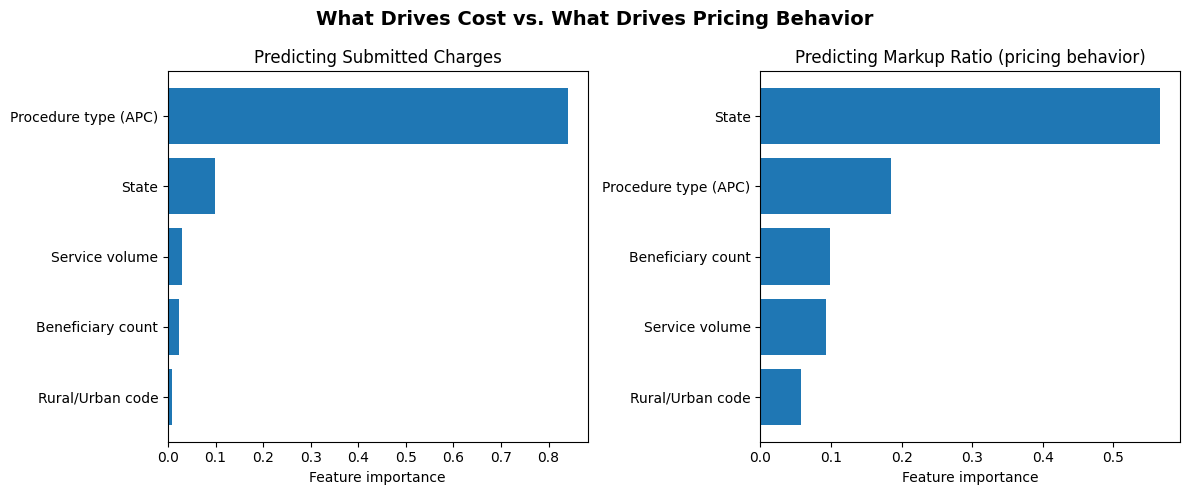


EDA complete.


In [ ]:
print("\n================ Bonus: Predictors of Cost ================")

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

feat = core[
    ["APC_Cd", "Rndrng_Prvdr_State_Abrvtn",
     "Rndrng_Prvdr_RUCA", "CAPC_Srvcs", "Bene_Cnt"]
].copy()

feat["APC_Cd"] = feat["APC_Cd"].astype(str)

for c in ["APC_Cd", "Rndrng_Prvdr_State_Abrvtn"]:
    feat[c] = LabelEncoder().fit_transform(feat[c])

feat["Rndrng_Prvdr_RUCA"] = feat["Rndrng_Prvdr_RUCA"].fillna(
    feat["Rndrng_Prvdr_RUCA"].median()
)

# Random Forest models
rf_charge = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
).fit(feat, core["Avg_Tot_Sbmtd_Chrgs"])

rf_markup = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42,n_jobs=-1).fit(feat, core["Markup_Ratio"])

# Feature importance
imp_charge = pd.Series( rf_charge.feature_importances_,index=feat.columns).sort_values(ascending=False)

imp_markup = pd.Series(rf_markup.feature_importances_,index=feat.columns).sort_values(ascending=False)

print(
    "Feature importance -> Submitted Charges (R²={:.2f}):".format(
        rf_charge.score(feat, core["Avg_Tot_Sbmtd_Chrgs"])
    )
)
print(imp_charge)

print(
    "\nFeature importance -> Markup Ratio (R²={:.2f}):".format(
        rf_markup.score(feat, core["Markup_Ratio"])))
print(imp_markup)


# Chart labels
label_map = {
    "APC_Cd": "Procedure type (APC)",
    "Rndrng_Prvdr_State_Abrvtn": "State",
    "CAPC_Srvcs": "Service volume",
    "Bene_Cnt": "Beneficiary count",
    "Rndrng_Prvdr_RUCA": "Rural/Urban code"
}

# Display charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

i1 = imp_charge.sort_values()
i2 = imp_markup.sort_values()

axes[0].barh(
    [label_map[i] for i in i1.index],
    i1.values
)
axes[0].set_title("Predicting Submitted Charges")
axes[0].set_xlabel("Feature importance")

axes[1].barh(
    [label_map[i] for i in i2.index],
    i2.values
)
axes[1].set_title("Predicting Markup Ratio (pricing behavior)")
axes[1].set_xlabel("Feature importance")

fig.suptitle(
    "What Drives Cost vs. What Drives Pricing Behavior",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
print("\nEDA complete.")


### 6.1 Interpreting the models

Left chart (Submitted Charges) answers question #1: "why is one procedure billed for more dollars than another?" And the answer is boring and expected: it's mostly just what the procedure is (APC_Cd = 84% importance). A complex musculoskeletal surgery naturally costs more to bill than a simple observation stay. That's not really "behavior" — it's just reality.

Right chart (Markup Ratio) answers a totally different question. Remember, markup ratio = submitted charge ÷ what Medicare actually allows. So this isn't "how much did they bill in dollars" — it's "how aggressively did this hospital mark up its price relative to the fair/regulated rate for that exact same procedure?" Once you frame it that way, you've removed "which procedure is it" from the question — you're comparing apples to apples (same procedure, different hospitals). And when you do that, the answer flips: State becomes the #1 predictor (57%), bigger than the procedure itself.


So "pricing behavior" simply means: the choice a hospital makes about how high to set its sticker price, separate from what the procedure actually is. It's the "restaurant's decision," not "the dish itself."
Why that's the interesting finding: it means two hospitals doing the exact same procedure aren't priced differently mainly because one procedure was harder than the other — they're priced differently mainly because of where they're located (which state, which local market/regulatory environment).")

## 7. Executive Summary

| # | Question | Key finding |
|---|---|---|
| Q1 | Billed vs. allowed vs. paid | Hospitals bill **~6.1x (median)** what Medicare allows on average ($37.8K billed vs. $5.8K allowed). |
| Q2 | Top spending procedures | Musculoskeletal procedures (Level 5) lead national spend (~$4.75B); Observation Services rank high purely on volume. |
| Q3 | State variation | Markup swings ~4x by state (NV 11.9x → MA 3.0x) for the same national procedure codes. |
| Q4 | Rural vs. urban | Urban hospitals bill ~2x rural hospitals, though Medicare's allowed amount barely differs by setting. |
| Q5 | Extreme markups | Max markup 122x; extremes concentrate in specific health systems (e.g., Carepoint Health, NJ). |
| Q6 | CMS outlier payments | Endovascular and Radiation Therapy procedures drive most of CMS's own outlier-payment spend. |
| Q7 | Spending concentration | Top 50 hospitals hold only 12.6% of national spend — fairly distributed, not dominated by a few giants. |
| Peer outliers | Same-procedure comparison | 2.0% of records are extreme vs. same-APC peers; concentrated in FL/CA/TX and urban markets, often shared ownership. |
| Predictors | What drives cost vs. pricing | Procedure type (APC) explains **84%** of *dollar amount billed* (R²=0.67) — mostly just "what the service is." But once procedure type is held constant, **state** explains **57%** of *markup ratio* (R²=0.34) — pricing behavior is chiefly a location/market decision, not a reflection of case complexity. |

**Bottom line:** Outpatient billing shows a large and systematic gap between what hospitals charge and what Medicare pays. That gap is not random — it's concentrated in specific states, specific urban markets, and specific health systems, and it persists even after controlling for which procedure was performed. This is consistent with hospitals setting chargemaster prices as a strategic/negotiating tool rather than a cost-based figure, most visibly in a handful of markets and ownership groups (NV, FL, TX, NJ; HCA- and Carepoint-affiliated facilities).